# 🧩 ধাপ ১: Face Detection (মুখ শনাক্তকরণ)

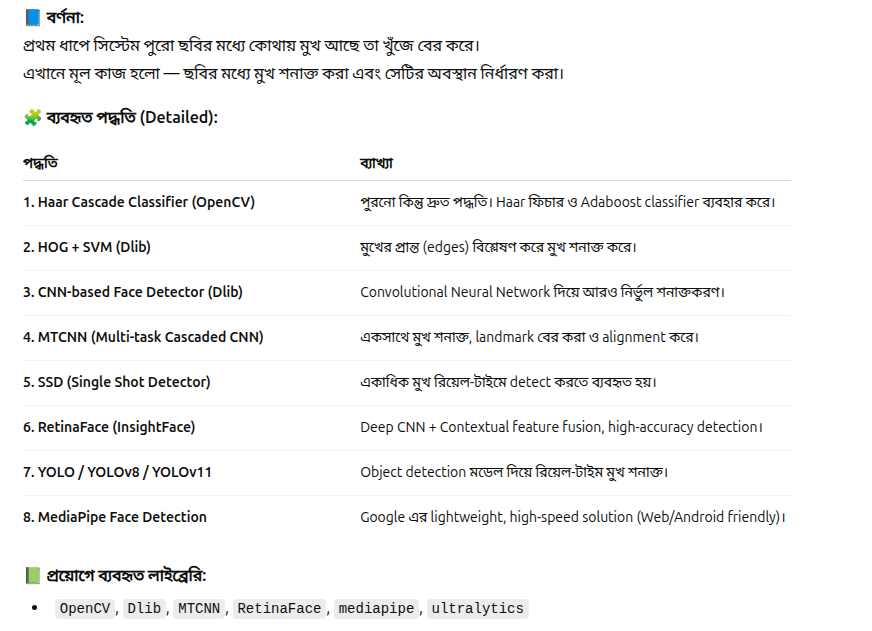

# 1. Haar Cascade Classifier (OpenCV)

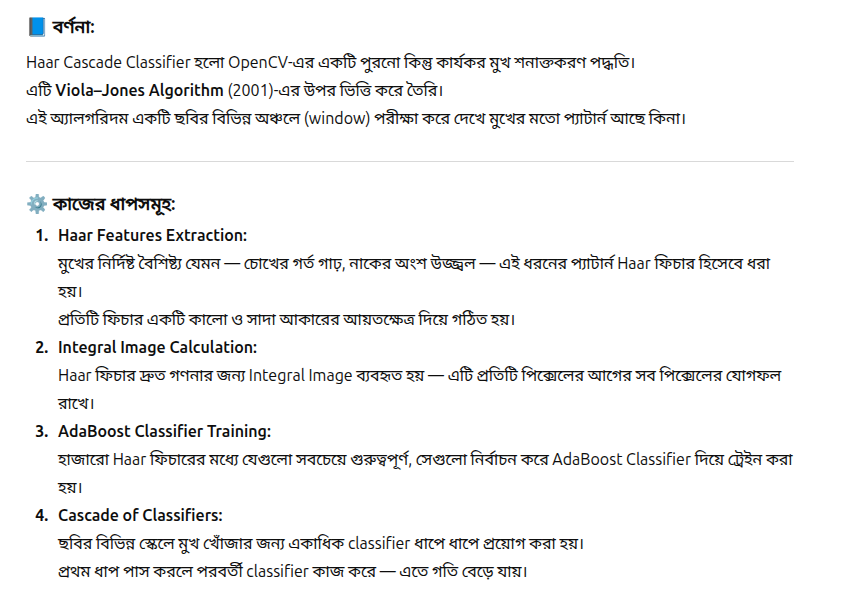

✅ মোট 1টি মুখ শনাক্ত হয়েছে।


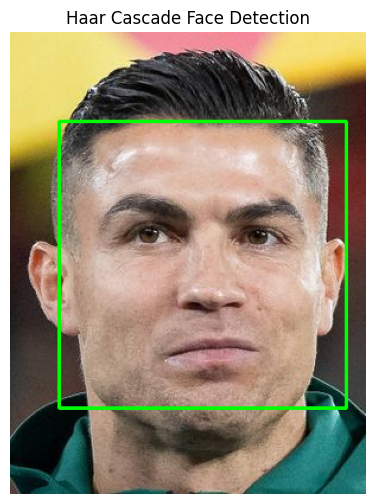

In [2]:
import cv2
import matplotlib.pyplot as plt

def detect_faces_haar(image_path):
    """
    🧩 মুখ শনাক্তকরণ (Haar Cascade Classifier + Matplotlib)
    ------------------------------------------
    ইনপুট:  ইমেজ ফাইলের পথ
    আউটপুট: মুখসহ ইমেজ (Matplotlib দিয়ে প্রদর্শন)
    """

    # 1️⃣ Haar Cascade লোড করা
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    # 2️⃣ ইমেজ লোড ও গ্রে রূপান্তর
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3️⃣ মুখ শনাক্ত করা
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    print(f"✅ মোট {len(faces)}টি মুখ শনাক্ত হয়েছে।")

    # 4️⃣ মুখের চারপাশে বক্স আঁকা
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # 5️⃣ OpenCV (BGR) → Matplotlib (RGB) রূপান্তর
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 6️⃣ Matplotlib দিয়ে প্রদর্শন
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("Haar Cascade Face Detection")
    plt.show()

# 🔹 ফাংশন কল করুন
detect_faces_haar('dataset/test/ronaldo/ronaldo.jpg')

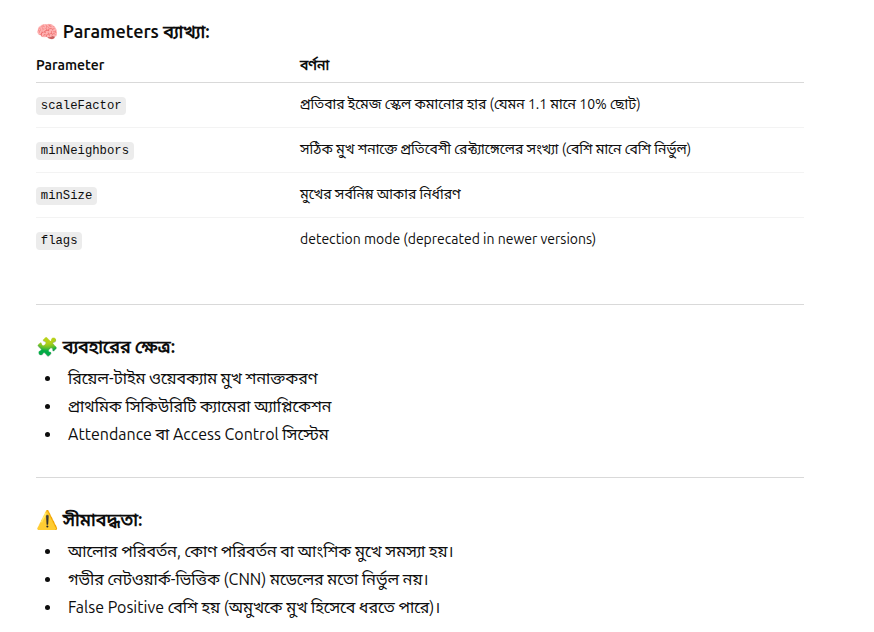

# 2. HOG + SVM (Dlib)

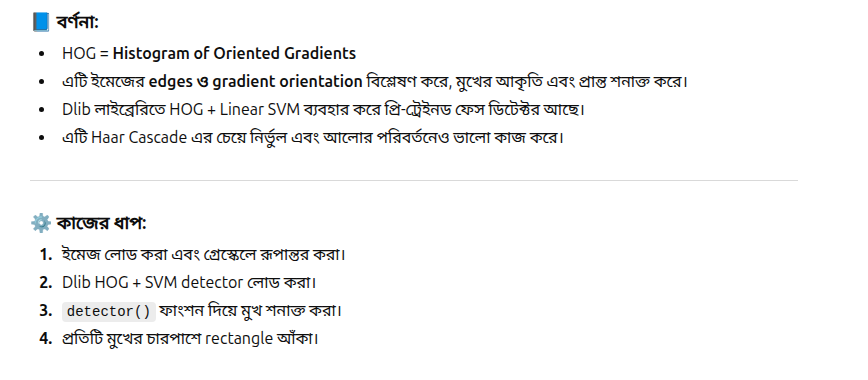

✅ মোট 1টি মুখ শনাক্ত হয়েছে।


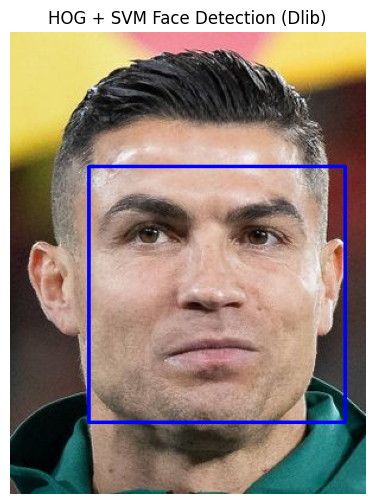

In [3]:
import dlib
import cv2
import matplotlib.pyplot as plt

def detect_faces_hog_svm(image_path):
    """
    🧩 মুখ শনাক্তকরণ (HOG + SVM, Dlib)
    --------------------------------------
    ইনপুট:  ইমেজ ফাইলের পথ
    আউটপুট: মুখসহ ইমেজ Matplotlib দিয়ে প্রদর্শন
    """

    # 1️⃣ Dlib HOG + SVM Detector লোড
    detector = dlib.get_frontal_face_detector()

    # 2️⃣ ইমেজ লোড ও গ্রেস্কেল
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3️⃣ মুখ শনাক্ত
    faces = detector(gray)

    print(f"✅ মোট {len(faces)}টি মুখ শনাক্ত হয়েছে।")

    # 4️⃣ বক্স আঁকা
    for face in faces:
        x, y, w, h = face.left(), face.top(), face.width(), face.height()
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

    # 5️⃣ BGR → RGB রূপান্তর
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 6️⃣ Matplotlib দিয়ে প্রদর্শন
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("HOG + SVM Face Detection (Dlib)")
    plt.show()

# 🔹 ফাংশন কল করুন
detect_faces_hog_svm('dataset/test/ronaldo/ronaldo.jpg')

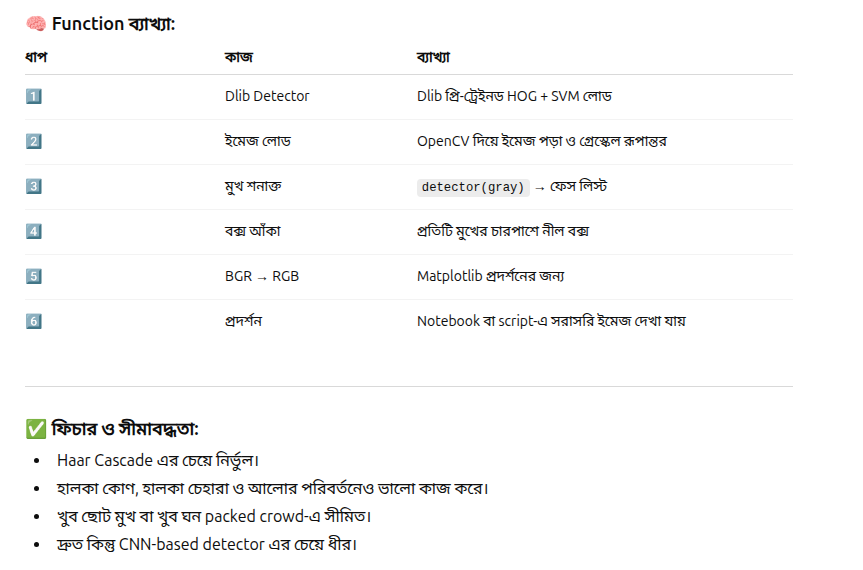

# 3. CNN-based Face Detector (Dlib)

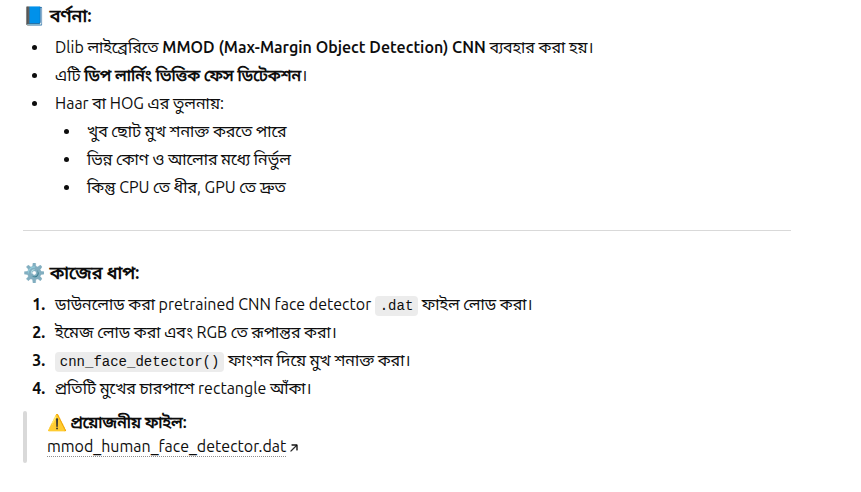

✅ মোট 1টি মুখ শনাক্ত হয়েছে।


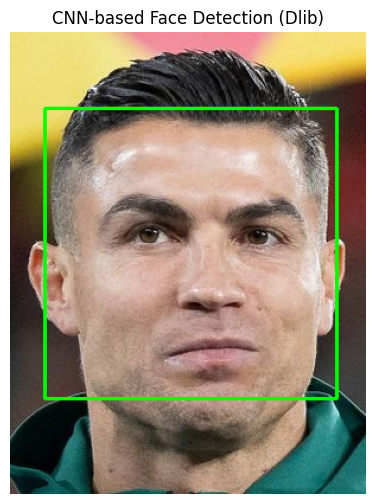

In [6]:
import dlib
import cv2
import matplotlib.pyplot as plt

def detect_faces_cnn(image_path, model_path='mmod_human_face_detector.dat'):
    """
    🧩 CNN-based Face Detection (Dlib)
    ---------------------------------------
    ইনপুট:  ইমেজ ফাইলের পথ এবং pretrained CNN model path
    আউটপুট: মুখসহ ইমেজ Matplotlib দিয়ে প্রদর্শন
    """

    # 1️⃣ CNN Detector লোড
    cnn_face_detector = dlib.cnn_face_detection_model_v1(model_path)

    # 2️⃣ ইমেজ লোড ও RGB রূপান্তর
    img = cv2.imread(image_path)
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3️⃣ মুখ শনাক্ত
    faces = cnn_face_detector(rgb_img, 1)  # 1 = upsample times

    print(f"✅ মোট {len(faces)}টি মুখ শনাক্ত হয়েছে।")

    # 4️⃣ বক্স আঁকা
    for face in faces:
        rect = face.rect
        x, y, w, h = rect.left(), rect.top(), rect.width(), rect.height()
        cv2.rectangle(rgb_img, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # 5️⃣ Matplotlib দিয়ে প্রদর্শন
    plt.figure(figsize=(8, 6))
    plt.imshow(rgb_img)
    plt.axis('off')
    plt.title("CNN-based Face Detection (Dlib)")
    plt.show()

# 🔹 ফাংশন কল করুন
detect_faces_cnn('dataset/test/ronaldo/ronaldo.jpg', 'mmod_human_face_detector.dat')

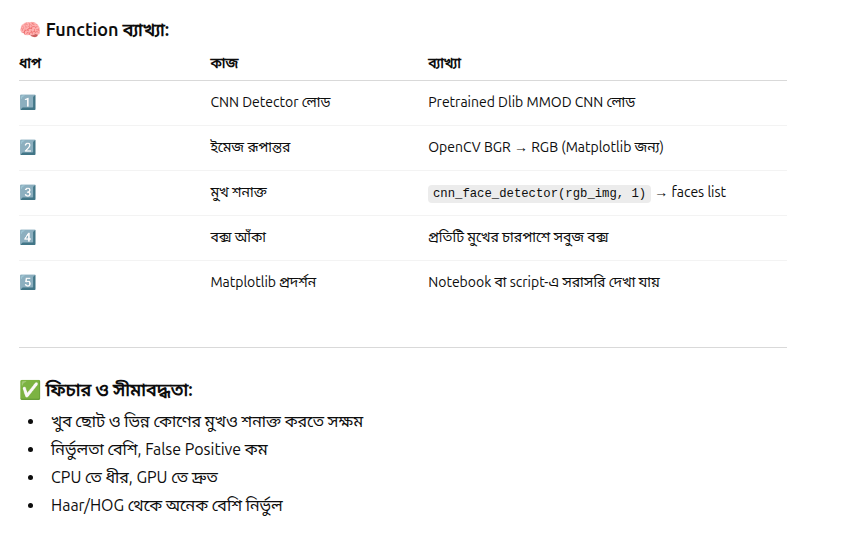

# 4. MTCNN (Multi-task Cascaded CNN)

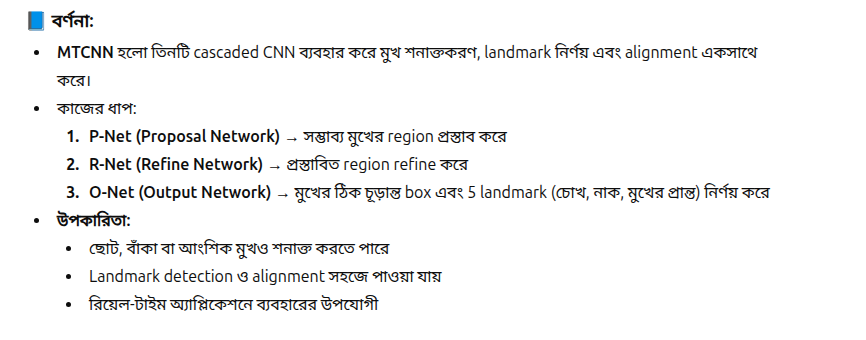

✅ মোট 1টি মুখ শনাক্ত হয়েছে।


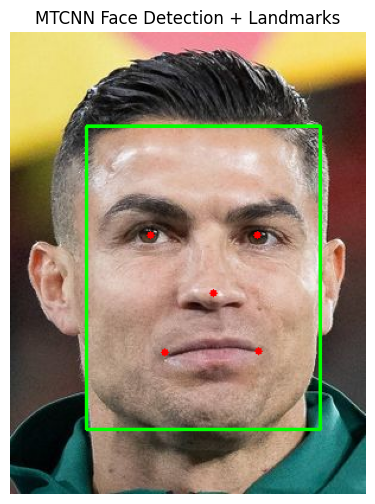

In [8]:
from mtcnn import MTCNN
import cv2
import matplotlib.pyplot as plt

def detect_faces_mtcnn(image_path):
    """
    🧩 MTCNN Face Detection + Landmark
    ---------------------------------------
    ইনপুট:  ইমেজ ফাইলের পথ
    আউটপুট: মুখসহ ইমেজ + landmark Matplotlib দিয়ে প্রদর্শন
    """

    # 1️⃣ MTCNN detector লোড
    detector = MTCNN()

    # 2️⃣ ইমেজ লোড ও RGB রূপান্তর
    img = cv2.imread(image_path)
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3️⃣ মুখ শনাক্ত ও landmark বের করা
    results = detector.detect_faces(rgb_img)

    print(f"✅ মোট {len(results)}টি মুখ শনাক্ত হয়েছে।")

    # 4️⃣ বক্স ও landmark আঁকা
    for result in results:
        x, y, w, h = result['box']
        cv2.rectangle(rgb_img, (x, y), (x+w, y+h), (0, 255, 0), 2)

        # Landmark: eyes, nose, mouth corners
        for key, point in result['keypoints'].items():
            cv2.circle(rgb_img, point, 3, (255, 0, 0), -1)

    # 5️⃣ Matplotlib দিয়ে প্রদর্শন
    plt.figure(figsize=(8, 6))
    plt.imshow(rgb_img)
    plt.axis('off')
    plt.title("MTCNN Face Detection + Landmarks")
    plt.show()

# 🔹 ফাংশন কল করুন
detect_faces_mtcnn('dataset/test/ronaldo/ronaldo.jpg')

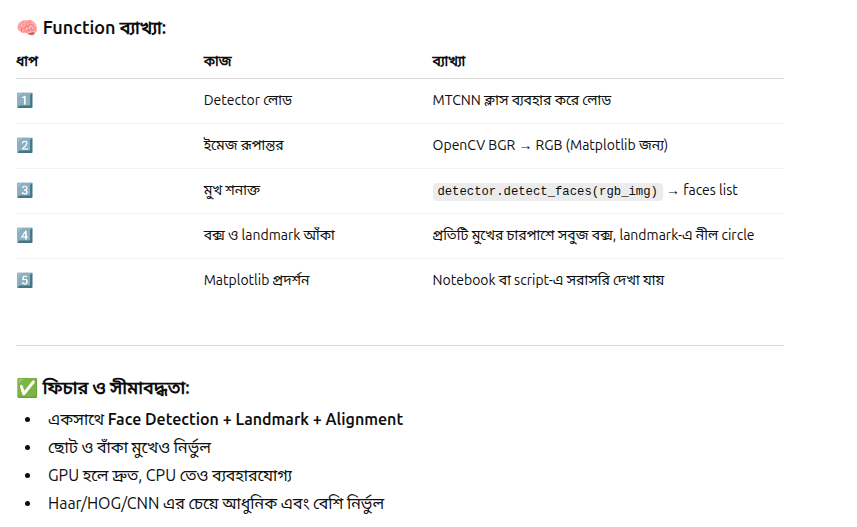

# 5. SSD (Single Shot Detector)

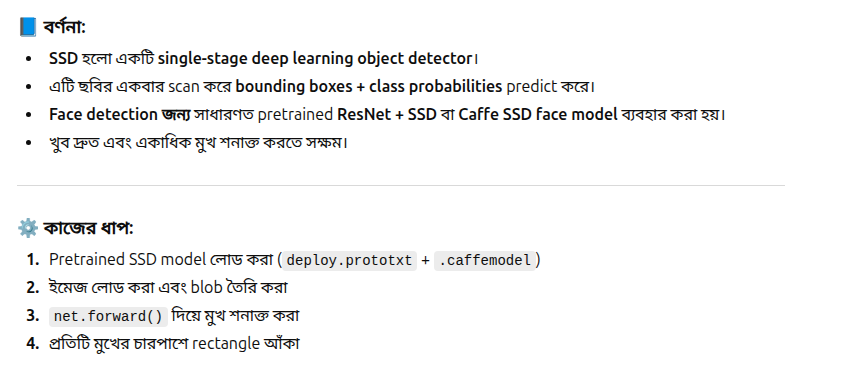

✅ মোট 1টি মুখ শনাক্ত হয়েছে।


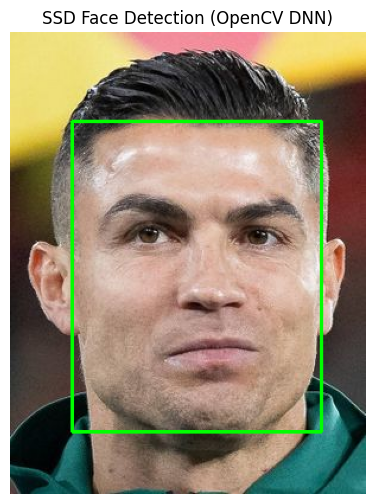

In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def detect_faces_ssd(image_path, prototxt='deploy.prototxt', model='res10_300x300_ssd_iter_140000.caffemodel', conf_threshold=0.5):
    """
    🧩 SSD Face Detection (OpenCV DNN)
    -----------------------------------
    ইনপুট:  ইমেজ ফাইলের পথ, SSD prototxt ও caffemodel
    আউটপুট: মুখসহ ইমেজ Matplotlib দিয়ে প্রদর্শন
    """

    # 1️⃣ SSD model লোড
    net = cv2.dnn.readNetFromCaffe(prototxt, model)

    # 2️⃣ ইমেজ লোড
    img = cv2.imread(image_path)
    (h, w) = img.shape[:2]

    # 3️⃣ Blob তৈরি
    blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)), 1.0,
                                 (300, 300), (104.0, 177.0, 123.0))

    # 4️⃣ Forward pass
    net.setInput(blob)
    detections = net.forward()

    count = 0
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > conf_threshold:
            count += 1
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (x1, y1, x2, y2) = box.astype("int")
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    print(f"✅ মোট {count}টি মুখ শনাক্ত হয়েছে।")

    # 5️⃣ BGR → RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 6️⃣ Matplotlib দিয়ে প্রদর্শন
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("SSD Face Detection (OpenCV DNN)")
    plt.show()

# 🔹 ফাংশন কল করুন
detect_faces_ssd('dataset/test/ronaldo/ronaldo.jpg', 'deploy.prototxt', 'res10_300x300_ssd_iter_140000.caffemodel')

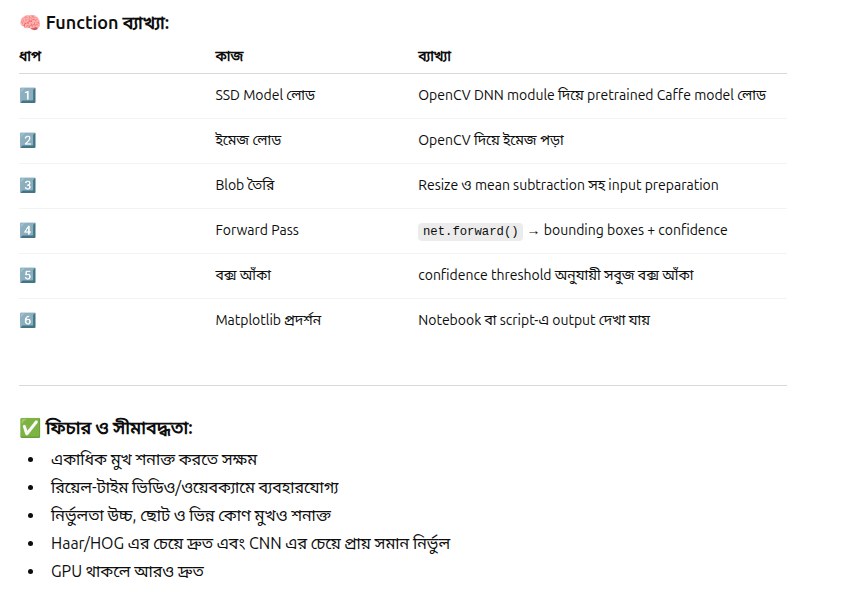

# 6. RetinaFace (InsightFace)

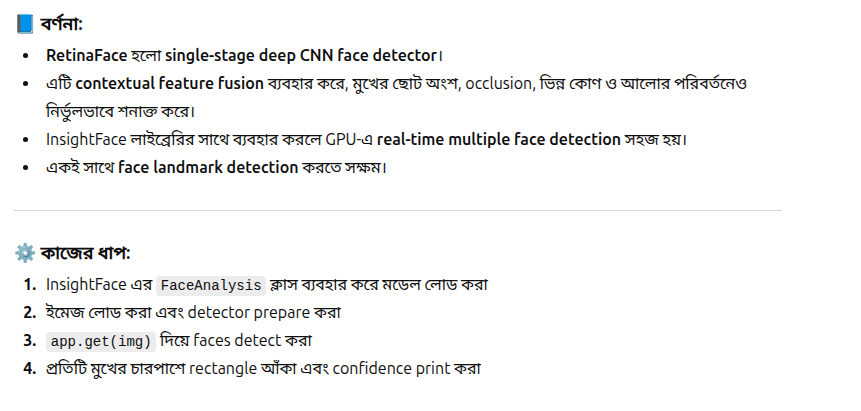

In [14]:
import cv2
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis

def detect_faces_retinaface(image_path, providers=['CPUExecutionProvider']):
    """
    🧩 RetinaFace Face Detection (InsightFace)
    ------------------------------------------
    ইনপুট:  ইমেজ ফাইলের পথ
    আউটপুট: মুখসহ ইমেজ Matplotlib দিয়ে প্রদর্শন
    """

    # 1️⃣ RetinaFace Detector লোড
    app = FaceAnalysis(providers=providers)
    app.prepare(ctx_id=0, det_size=(640, 640))

    # 2️⃣ ইমেজ লোড
    img = cv2.imread(image_path)
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3️⃣ মুখ শনাক্ত
    faces = app.get(rgb_img)
    print(f"✅ মোট {len(faces)}টি মুখ শনাক্ত হয়েছে।")

    # 4️⃣ বক্স ও landmark আঁকা
    for face in faces:
        bbox = face.bbox.astype(int)
        x1, y1, x2, y2 = bbox
        cv2.rectangle(rgb_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Landmark
        for (x, y) in face.kps.astype(int):
            cv2.circle(rgb_img, (x, y), 3, (255, 0, 0), -1)

    # 5️⃣ Matplotlib দিয়ে প্রদর্শন
    plt.figure(figsize=(8, 6))
    plt.imshow(rgb_img)
    plt.axis('off')
    plt.title("RetinaFace Detection (InsightFace)")
    plt.show()

# 🔹 ফাংশন কল করুন
detect_faces_retinaface('dataset/test/ronaldo/ronaldo.jpg')

ModuleNotFoundError: No module named 'insightface'

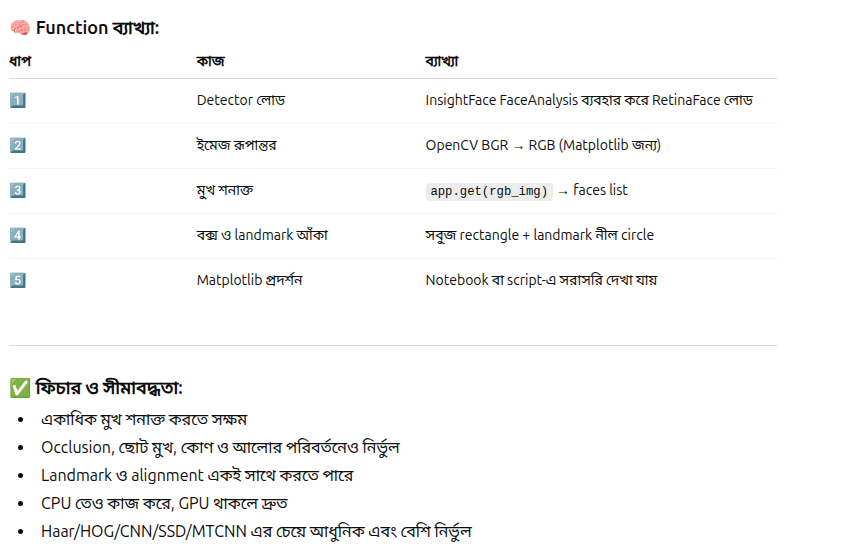

# 7. YOLO / YOLOv8 / YOLOv11 for Face Detection

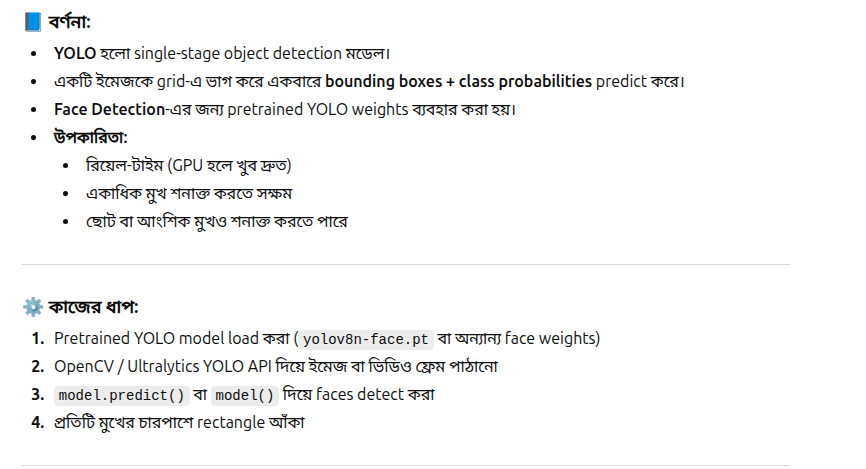

In [18]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

def detect_faces_yolo(image_path, model_path='yolov8n-face.pt'):
    """
    🧩 YOLO Face Detection
    --------------------------
    ইনপুট:  ইমেজ ফাইলের পথ, pretrained YOLO face model
    আউটপুট: মুখসহ ইমেজ Matplotlib দিয়ে প্রদর্শন
    """

    # 1️⃣ YOLO model লোড
    model = YOLO(model_path)

    # 2️⃣ ইমেজ লোড
    img = cv2.imread(image_path)
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3️⃣ মুখ শনাক্ত
    results = model.predict(source=rgb_img, imgsz=640, conf=0.5)

    # 4️⃣ বক্স আঁকা
    for r in results:
        boxes = r.boxes.xyxy.cpu().numpy()  # [x1, y1, x2, y2]
        for box in boxes:
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(rgb_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    print(f"✅ মোট {len(boxes)}টি মুখ শনাক্ত হয়েছে।")

    # 5️⃣ Matplotlib দিয়ে প্রদর্শন
    plt.figure(figsize=(8, 6))
    plt.imshow(rgb_img)
    plt.axis('off')
    plt.title("YOLO Face Detection")
    plt.show()

# 🔹 ফাংশন কল করুন
detect_faces_yolo('dataset/test/ronaldo/ronaldo.jpg', 'yolov8n-face.pt')

ModuleNotFoundError: No module named 'ultralytics'

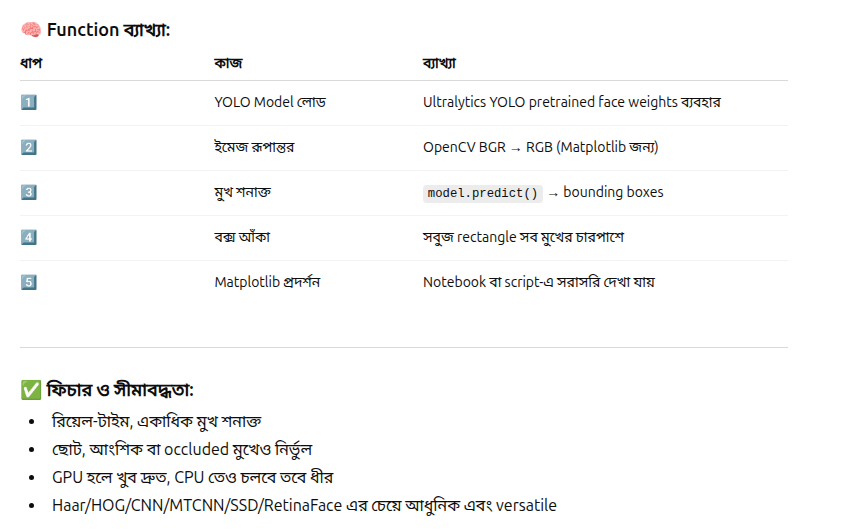

# 8. MediaPipe Face Detection

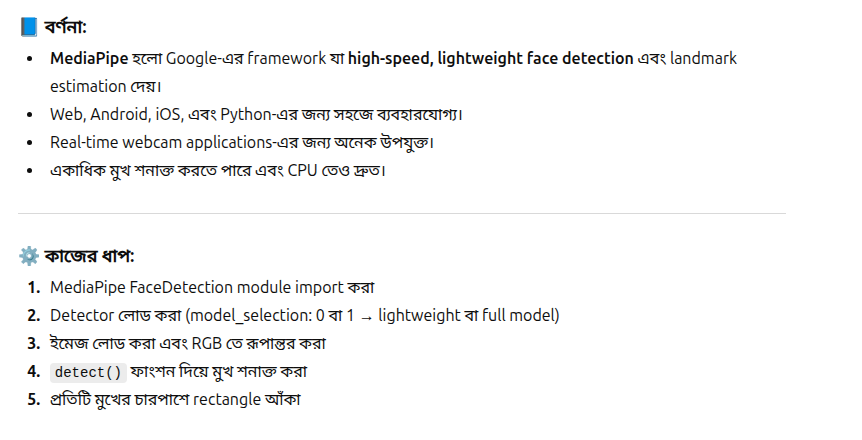

✅ মোট 1টি মুখ শনাক্ত হয়েছে।


I0000 00:00:1762497731.298546   34299 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1762497731.300021   36161 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
W0000 00:00:1762497731.303013   36156 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


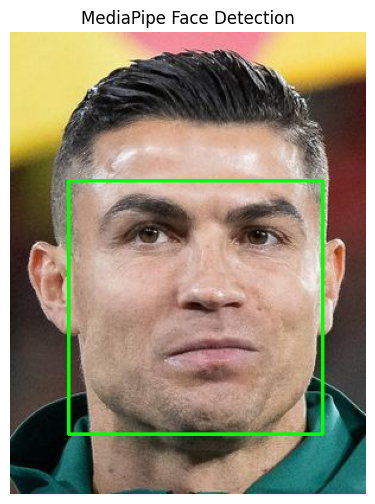

In [20]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

def detect_faces_mediapipe(image_path, min_detection_confidence=0.5, model_selection=0):
    """
    🧩 MediaPipe Face Detection
    ----------------------------
    ইনপুট:  ইমেজ ফাইলের পথ
    আউটপুট: মুখসহ ইমেজ Matplotlib দিয়ে প্রদর্শন
    """

    # 1️⃣ MediaPipe Face Detection লোড
    mp_face_detection = mp.solutions.face_detection
    mp_drawing = mp.solutions.drawing_utils

    with mp_face_detection.FaceDetection(
        model_selection=model_selection, 
        min_detection_confidence=min_detection_confidence) as face_detection:

        # 2️⃣ ইমেজ লোড ও RGB রূপান্তর
        img = cv2.imread(image_path)
        rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 3️⃣ মুখ শনাক্ত
        results = face_detection.process(rgb_img)

        count = 0
        # 4️⃣ বক্স আঁকা
        if results.detections:
            for detection in results.detections:
                count += 1
                bboxC = detection.location_data.relative_bounding_box
                h, w, _ = rgb_img.shape
                x1, y1 = int(bboxC.xmin * w), int(bboxC.ymin * h)
                x2, y2 = x1 + int(bboxC.width * w), y1 + int(bboxC.height * h)
                cv2.rectangle(rgb_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        print(f"✅ মোট {count}টি মুখ শনাক্ত হয়েছে।")

        # 5️⃣ Matplotlib দিয়ে প্রদর্শন
        plt.figure(figsize=(8, 6))
        plt.imshow(rgb_img)
        plt.axis('off')
        plt.title("MediaPipe Face Detection")
        plt.show()

# 🔹 ফাংশন কল করুন
detect_faces_mediapipe('dataset/test/ronaldo/ronaldo.jpg')

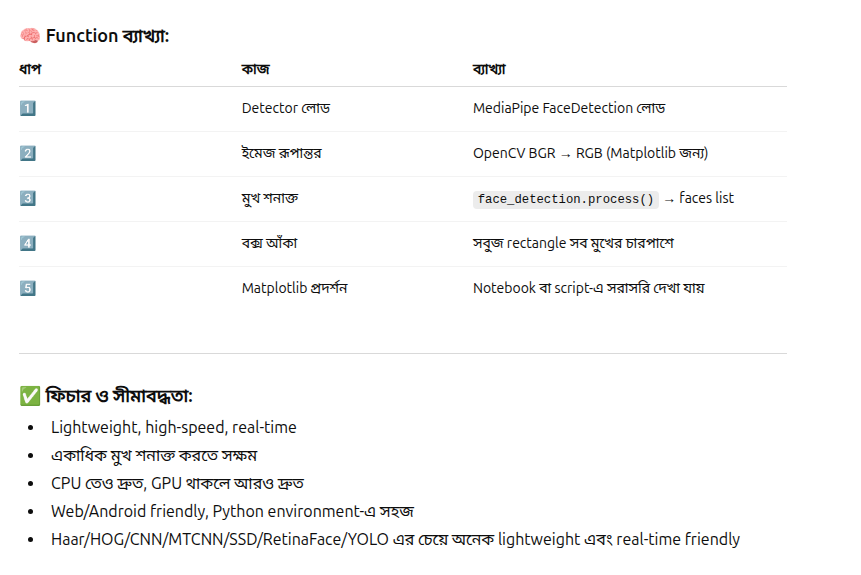